# 👋 Introduction
### 🗞️ News Authenticator for Fox News

## Problem Statement

In the age of extremely high utilization of digital media, fake news and misinformation are a huge threat to public trust and news organizations credibility. As a US headquartered large news organization by the name `Fox News`, our role is to improve our services by incorporating an aspect of news validity that would allow users to verify any news article for validity.

This new feature is very crucial for maintaining public trust as a reliable news source and helping users make informed decisions.

## Benefits of solving this problem:
- Increase user and public trust while also increasing engagement by providing immediate feedback on news authenticity.
- Help prevent misinformation.
- Differentiate our platform from other news organization by offering advanced and quick fact-checking capabilities.

## High-Level System Design

Our NLP based, fact checking feature will consist of the following:

- **Data Collection and Labeling**: Collect and label news article texts as real or fake.
- **Data Preprocessing and Cleaning**: Handle noise, missing values and clean the text.
- **Feature Engineering**: Transform cleaned text into numerical features for machine learning.
- **Multiple Model Training and Selection**: Train and evaluate multiple machine learning models to identify the best performer.
- **Prediction Test**: Use the best model to predict real and fake predictions.
- **Evaluation, Monitoring and Maintaining**: Frequently evaluate model performance and update when needed.


# 📑 Imports

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


# 📑 Data Loading

To create this solution, we can collect labeled datasets of real and fake news articles from reputable sources like Kaggle, verified news outlets and fact checking organizations. We can formulate the problem as a binary test classification tasks in NLP, where the goal is to classify an input news article as `real` or `fake`.



Link to my dataset: https://www.kaggle.com/datasets/razanaqvi14/real-and-fake-news/data

In [2]:
fake=pd.read_csv('C:\\Users\\judec\\Downloads\\NLP\\Fake.csv')
real=pd.read_csv('C:\\Users\\judec\\Downloads\\NLP\\True.csv')

In [3]:
print("Shape of the fake news dataframe:", fake.shape)
print("Shape of the real news dataframe:", real.shape)

Shape of the fake news dataframe: (23481, 4)
Shape of the real news dataframe: (21417, 4)


# 🕵️ Data Pre-processing

We can combine relevant columns like `title` and `text` and separate a `test_samples` df for additional testing

Add labels with `fake == 1` and `real == 0`

In [4]:
fake['label'] = 1
real['label'] = 0

Concat fake and real datasets

In [5]:
# Combine datasets using concat
df = pd.concat([fake, real], axis=0)

# Shuffle and reset the index
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

List of types of news available in the dataset

In [6]:
print(df['subject'].unique())

['US_News' 'politicsNews' 'News' 'Government News' 'left-news' 'worldnews'
 'politics' 'Middle-east']


In [7]:
print("Shape of the combined dataframe:", df.shape)
print("All columns of the combined dataframe:", df.columns)
df.head()

Shape of the combined dataframe: (44898, 5)
All columns of the combined dataframe: Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


We can split a chunk of 12 samples of `50/50` `fake` and `real` to perform a test, on the best model, later in the code.

In [8]:
# Extract 6 samples from each label for testing (total 12 samples)
sample_fake = df[df['label'] == 1].sample(6, random_state=42)
sample_real = df[df['label'] == 0].sample(6, random_state=42)

# Combine and reset index
test_samples = pd.concat([sample_fake, sample_real]).reset_index(drop=True)

# Remove these samples from the original df to prevent data leakage
df = df.drop(sample_fake.index)
df = df.drop(sample_real.index)
df = df.reset_index(drop=True)

test_samples[['title', 'text', 'label']]

,title,text,label
0,"NY Daily News Goes ALL IN On NRA, ‘Thanks’ Th...",The NY Daily News is never shy when it comes t...,1
1,IT’S ABOUT TIME! 19 GOP Congressmen Call For C...,All we can say about this development is that ...,1
2,INSANE ANTI-TRUMP PROTESTER Lights Trump Suppo...,The Inauguration was a beautiful day full of g...,1
3,AMERICA IN CRISIS: “Hillary Clinton Is A CRIMI...,Are Democrat voters willing to risk what littl...,1
4,Paul Ryan Refuses To Hold Town Halls Because ...,House Speaker Paul Ryan finally admitted the r...,1
5,Trump Was Whining About White House Leaks. Ch...,It s mind baffling that Donald Trump still has...,1
6,Trump to speak with British prime minister May...,WASHINGTON (Reuters) - U.S. President Donald T...,0
7,Trump says Britain should leave EU: newspaper ...,LONDON (Reuters) - Donald Trump told Britons o...,0
8,Trump on Twitter (Feb 24) - FBI leaks,The following statements were posted to the ve...,0
9,Poland wants strong euro zone before mulling m...,WARSAW (Reuters) - Poland wants the euro zone ...,0


# 🧹 Data Cleaning

Remove unnecessary columns and combine the `title` column and `text` column for greater context into `combined_content` column.

In [9]:
df["combined_content"] = df["title"] + " " + df["text"]

Check null and drop nulls values

In [10]:
df.isnull().sum()

title               0
text                0
subject             0
date                0
label               0
combined_content    0
dtype: int64

In [11]:
df.dropna(inplace=True)

Combined dataframe with pre-processing, cleaning and required columns

In [12]:
df = df[["combined_content", "label"]]
df.head()

,combined_content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,1
1,Trump drops Steve Bannon from National Securit...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,1
4,Donald Trump heads for Scotland to reopen a go...,0


Downloading required NLTK resources
- `punkt_tab` provides pre-trained models for tokenizing text
- `stopwords` contains a list of common stopwords (for e.g., 'the', 'is', 'and')
- `wordnet` is used for lemmatization which reduces words to their base form

In [13]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\judec\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\judec\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\judec\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

The `cleaner` function is used to clean text by:
- Lowering the text
- Removing special characters and numbers from the text
- Tokenizing the text
- Removing all english stop words
- Lemmatizing each token
- Joining all the processed tokens

We finally apply the function on our `df` column called `combined_content` into a new column called `clean_content`

In [14]:
def cleaner(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    # Join tokens back into text
    return ' '.join(tokens)

df['clean_content'] = df['combined_content'].apply(cleaner)

Display the `clean_content` data in it's dataframe

In [15]:
df[['combined_content', 'clean_content', 'label']].head()

,combined_content,clean_content,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,ben stein call th circuit court committed coup...,1
1,Trump drops Steve Bannon from National Securit...,trump drop steve bannon national security coun...,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,puerto rico expects u lift jones act shipping ...,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,oops trump accidentally confirmed leaked israe...,1
4,Donald Trump heads for Scotland to reopen a go...,donald trump head scotland reopen golf resort ...,0


# ☁️ WordCloud

We will now filter the dataframe to separate the `fake` news and `real` news to create WordClouds

Here we remember that `label == 1` is `Fake News` and `label == 0` is `Real News`

In [16]:
fake_text = df[df["label"] == 1]["clean_content"]
real_text = df[df["label"] == 0]["clean_content"]

We now generate the WordClouds for `Fake News` and then `Real News`

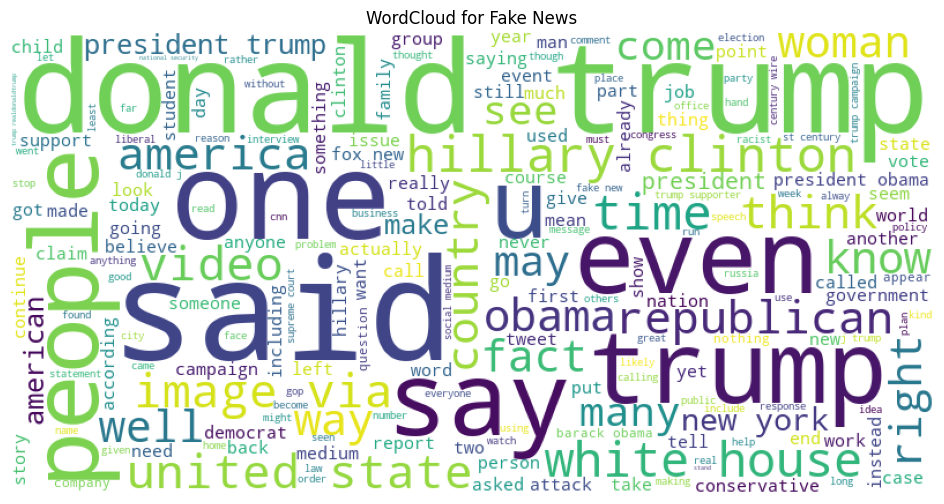

In [17]:
# Generate WordCloud for Fake News
plt.figure(figsize=(14,6))
plt.imshow(WordCloud(width=800, height=400, background_color="white").generate(' '.join(fake_text)))
plt.axis("off")
plt.title("WordCloud for Fake News")
plt.show()

The above WordCloud visualizes an overview of the most frequent occurrences of words in the Fake News dataset.

Some of the prominent words are:
- Trump
- Obama
- Say
- president
- US
- Hillary
- Time

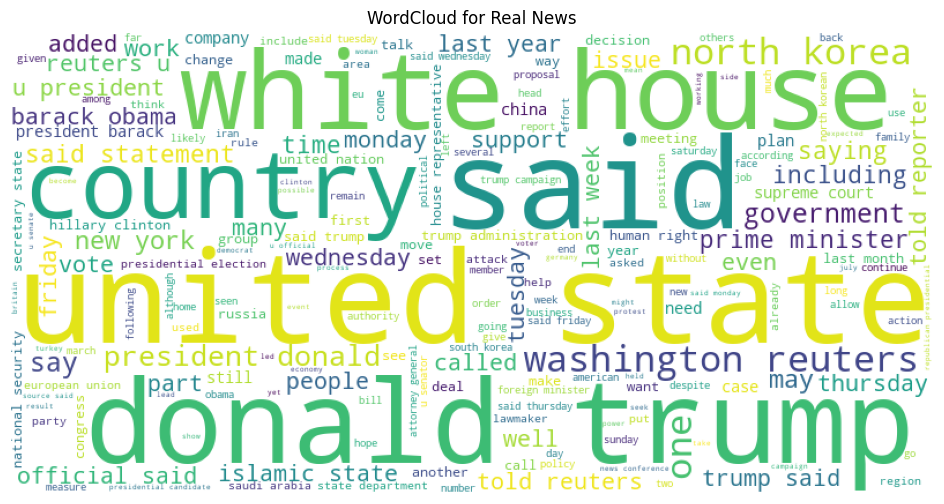

In [18]:
# Generate WordCloud for Real News
plt.figure(figsize=(14,6))
plt.imshow(WordCloud(width=800, height=400, background_color="white").generate(' '.join(real_text)))
plt.axis("off")
plt.title("WordCloud for Real News")
plt.show()

The above WordCloud visualizes an overview of the most frequent occurrences of words in the Real News dataset.

Some of the prominent words are:
- Country
- United State
- white house
- last year
- May
- government

When we compare these two WordClouds, we can visually distinguish and identify various different vocabulary between fake and real news.

This can be useful to perform feature engineering in fake news detection.

# 🔢 Feature Encoding

We will now convert the clean text data into a numerical format which a machine learning model can understand.

Here, we chose to use `CountVectorizer` object which transforms a collection of text data into a matrix of token counts called a document-term matrix.

In [19]:
# Create count vectorizer object
cv = CountVectorizer()

# Transform text data into document-term matrix
X = cv.fit_transform(df['clean_content'])

# Create target variable
y = df['label']

# ✂️ Train-Validation-Test Split

We will split the dataset into a `70/15/15` `train/validation/test` split.

In [20]:
# Split the dataset into training and testing sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# Split the validation dataset into validation and test sets
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)

# 🏗️ Model Building

In [21]:
warnings.filterwarnings('ignore')

We will now check multiple machine learning models to find the best performing model on validation data

In [22]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC(),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    }

The below code runs a loop based on the above models mentioned in the dictionary. It's working is as follows:
- It tracks the time taken by the model
- Fits the model on training data
- Using the model it predicts on validation dataset
- It calculates the **accuracy of the model** using validation set based on the predictions
- It then displays a **classification report** and a **confusion matrix**

Now training model: Logistic Regression
Training time for Logistic Regression: 0.84 seconds

 Accuracy of Logistic Regression: 0.9952
              precision    recall  f1-score   support

        Real       0.99      1.00      1.00      3222
        Fake       1.00      0.99      1.00      3511

    accuracy                           1.00      6733
   macro avg       1.00      1.00      1.00      6733
weighted avg       1.00      1.00      1.00      6733



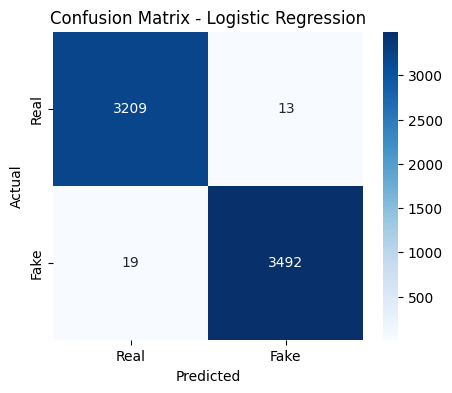

Now training model: SVM
Training time for SVM: 0.78 seconds

 Accuracy of SVM: 0.9955
              precision    recall  f1-score   support

        Real       0.99      1.00      1.00      3222
        Fake       1.00      0.99      1.00      3511

    accuracy                           1.00      6733
   macro avg       1.00      1.00      1.00      6733
weighted avg       1.00      1.00      1.00      6733



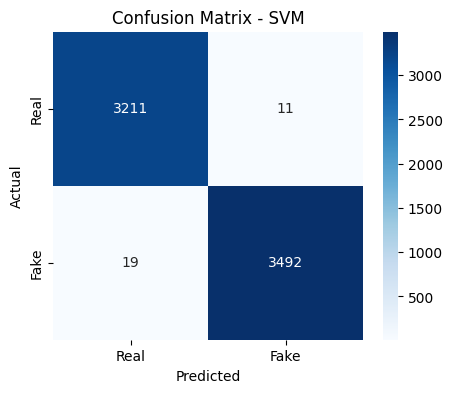

Now training model: Naive Bayes
Training time for Naive Bayes: 0.02 seconds

 Accuracy of Naive Bayes: 0.9554
              precision    recall  f1-score   support

        Real       0.95      0.96      0.95      3222
        Fake       0.96      0.95      0.96      3511

    accuracy                           0.96      6733
   macro avg       0.96      0.96      0.96      6733
weighted avg       0.96      0.96      0.96      6733



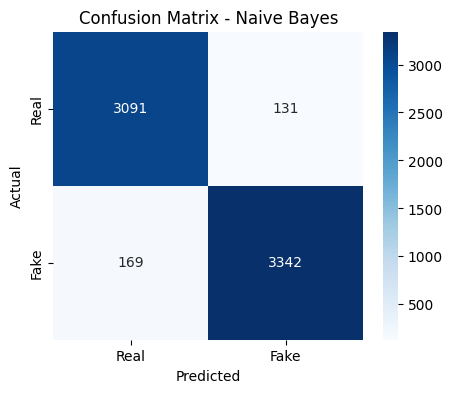

Now training model: Random Forest
Training time for Random Forest: 96.22 seconds

 Accuracy of Random Forest: 0.9854
              precision    recall  f1-score   support

        Real       0.98      0.99      0.98      3222
        Fake       0.99      0.98      0.99      3511

    accuracy                           0.99      6733
   macro avg       0.99      0.99      0.99      6733
weighted avg       0.99      0.99      0.99      6733



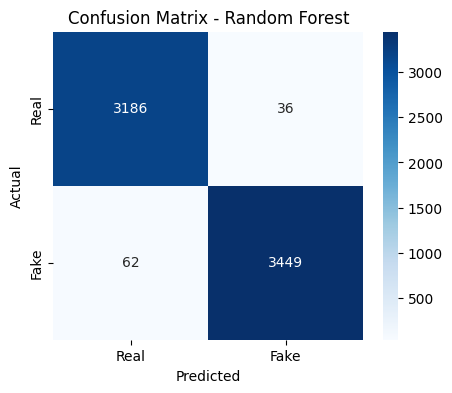

In [23]:
for name, model in models.items():
    print(f"Now training model: {name}")

    #Tracking the time taken to train the model
    start_time = time.time()
    # Training the model
    model.fit(X_train, y_train)
    elapsed_time = time.time() - start_time
    print(f"Training time for {name}: {elapsed_time:.2f} seconds")
    
    # Predict using validation set
    y_pred = model.predict(X_val)
    
    # Calculate accuracy using validation set
    acc = accuracy_score(y_val, y_pred)
    print(f"\n Accuracy of {name}: {acc:.4f}")
    
    # Print classification report using validation set
    print(classification_report(y_val, y_pred, target_names=["Real", "Fake"]))
    
    # Plot confusion matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# 🏆 Best Model

From the above output, we can say that the best and fastest performing model is the `LogisticRegression` model with:
- **Training time for Logistic Regression:** `0.84` seconds
- **Accuracy of Logistic Regression:** `0.9952`

We will now use the best model to predict on the test set of data. 

In [24]:
# Create and train the best model
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train, y_train)

# Make predictions on test data
y_pred = best_model.predict(X_test)

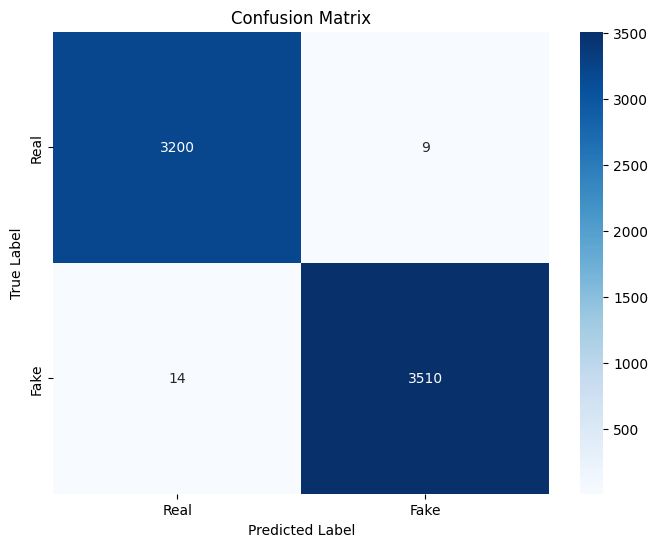


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3209
           1       1.00      1.00      1.00      3524

    accuracy                           1.00      6733
   macro avg       1.00      1.00      1.00      6733
weighted avg       1.00      1.00      1.00      6733



In [25]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix using seaborn
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print classification report
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

As we can see from the above output, 

### We get an accuracy of `100%` on the `test data`.

### **We can deploy this model to the platform to predict if US based news articles are fake or real.**

# 🤔 Conclusion and Additional Tests

We can perform an additional test to further show the robustness of the model on unseen data that we split earlier in the pipeline.

The function does the following:
- Take the text of the news as the input to the function
- Clean and transform the text
- Predict and get the probability based on the best model
- Return the results

In [26]:
def predict_news(text):
    # Clean the text using the previously defined cleaner function
    cleaned_text = cleaner(text)
    
    # Transform the text using the Count Vectorizer
    text_vector = cv.transform([cleaned_text])
    
    # Make prediction using the best model
    prediction = best_model.predict(text_vector)[0]
    probability = best_model.predict_proba(text_vector)[0]
    
    # Return result with probability
    if prediction == 0:
        return f"REAL news (Confidence: {probability[0]:.2%})"
    else:
        return f"FAKE news (Confidence: {probability[1]:.2%})"

We will now apply the `predict_news` function to the `test_samples` that we filtered previously in the code.

We can view the predictions in the `test_samples` dataframe below.

In [27]:
# Apply predict_news to each text in test_samples and collect predictions in the prediction column
test_samples['prediction'] = test_samples['text'].apply(predict_news)

# Display the actual label and the prediction for each sample
test_samples[['text', 'label', 'prediction']]

,text,label,prediction
0,The NY Daily News is never shy when it comes t...,1,FAKE news (Confidence: 100.00%)
1,All we can say about this development is that ...,1,FAKE news (Confidence: 100.00%)
2,The Inauguration was a beautiful day full of g...,1,FAKE news (Confidence: 100.00%)
3,Are Democrat voters willing to risk what littl...,1,FAKE news (Confidence: 100.00%)
4,House Speaker Paul Ryan finally admitted the r...,1,FAKE news (Confidence: 100.00%)
5,It s mind baffling that Donald Trump still has...,1,FAKE news (Confidence: 100.00%)
6,WASHINGTON (Reuters) - U.S. President Donald T...,0,REAL news (Confidence: 99.90%)
7,LONDON (Reuters) - Donald Trump told Britons o...,0,REAL news (Confidence: 100.00%)
8,The following statements were posted to the ve...,0,REAL news (Confidence: 99.90%)
9,WARSAW (Reuters) - Poland wants the euro zone ...,0,REAL news (Confidence: 99.98%)


We can see that all the predictions are accurate and the `99%` accuracy helps trust the results.

# 🏁 Final Takeaways

**Strengths:**
- Very high accuracy and robustness of the model in distinguishing real vs fake news.
- Scalable and modular NLP pipeline which allows for easy updates and management.
- Quick results helps build trust and reliability which, in turn, strengthens the companies reputation.

**Limitations:**
- The models performance depends greatly on the quality and diversity of the training data.
- The model may not generalize to news outside the training sets (outside US or outside news type).
- An important feature for users would be explanations for the predictions, which is missing.

**Recommendations:**
- Update the training dataset regularly with new text articles to maintain model's relevance.
- Track performance and receive user feedback in order to see potential improvements.
- Collaborate with other news vendors or fact-checking vendors to enhance data quality and results.

Therefore, by the addition of this NLP news article fact-checking feature, our company can become a significantly active member in the fight against misinformation and help in establishing a trusted relationship with existing and potential customers.


